# HD 189733b H$\alpha$ (and H$\beta$): EXHALE model vs. Jensen et al. (2012)

Self-contained comparison of the **EXHALE** transit transmission model for the
hydrogen Balmer lines against the HD 189733b observation of
**Jensen et al. (2012, ApJ 751, 86)**.

**Model.** The $n=2$ population is computed from the non-LTE balance of
Christie, Arras & Li (2013), driven by Ly$\alpha$ pumping; the Ly$\alpha$ mean
intensity is the Huang et al. (2017) estimate
$J_{\rm Ly\alpha}\simeq 0.1\,F_{\rm LyC}/\Delta\nu_D$ with $F_{\rm LyC}$ the
**absorbed stellar Lyman-continuum flux** (incident $10^{L_{\rm EUV}}/4\pi a^2$,
diluted by the day-night $\xi$ factor and the absorbed fraction). $n=2$
photoionization $\Gamma_{2s,2p}$ uses a diluted stellar-blackbody Balmer
continuum. H$\alpha$/H$\beta$ absorption is then integrated along impact-parameter
chords (Voigt profiles), exactly as in `TPM.py`.

**Inputs.** EXHALE converged output (`output/*_adv.txt`) + `input.inp`.

> **Observed data.** The Jensen+2012 numbers below are *representative
> literature values* to be **replaced with the digitized Jensen+2012 HD 189733b
> H$\alpha$ profile / equivalent width**. Drop a two-column file
> `jensen2012_HD189733b_Ha.txt` (wavelength [A], $\Delta F/F$) next to this
> notebook to overplot the real data automatically.

In [1]:
import numpy as np, matplotlib.pyplot as plt, os
from scipy.special import wofz
%matplotlib inline

# ---- constants (SI for line transfer; cgs for level populations) ----
kb=1.380649e-23; mp=1.672623e-27; c_light=2.99792458e8; h=6.626070e-34
e=-1.602176e-19; E0=8.854188e-12; me=9.109384e-31
RJ=6.9911e7; AU=1.495978707e11; R_sun=6.96e8
c_cgs,h_cgs,kb_cgs=2.99792458e10,6.62607015e-27,1.380649e-16
eV2Hz=2.417989242e14
g1s,g2s,g2p=2.0,2.0,6.0
lA=1215.6701e-10; nu_Lya=c_light/lA
A_2p1s=6.3e8; A_2s1s=8.26
B21_lya=A_2p1s*c_cgs**2/(2*h_cgs*nu_Lya**3); B12_lya=(g2p/g1s)*B21_lya
Fadd_const=np.sqrt(np.pi)*e**2/(4*np.pi*E0*me*c_light)
l_Ha=6562.8e-10; nu_Ha=c_light/l_Ha; f_Ha=0.6407; A12_Ha=4.4101e7
l_Hb=4861.35e-10; nu_Hb=c_light/l_Hb; f_Hb=0.11938; A12_Hb=8.4193e6

def n2_populations(T,n1s,ne,Jlya,G2s=0.0,G2p=0.0):
    '''n=2 H population [cm^-3] (Christie+2013 Eqs. 12-13).'''
    T=np.maximum(T,1.0); t4=T/1.0e4
    aB=2.54e-13*t4**(-0.8163-0.0208*np.log(t4))
    a2s=(0.282+0.047*t4-0.006*t4**2)*aB; a2p=aB-a2s
    C1s2s=1.21e-8*(1.0/t4)**0.455*np.exp(-118400.0/T)
    C1s2p=1.71e-8*(1.0/t4)**0.077*np.exp(-118400.0/T)
    C2s2p=6.21e-5*(np.log(T/1.02)-0.57721)/np.sqrt(T)
    C2s1s=1.21e-8*(1.0/t4)**0.455*(g1s/g2s)
    C2p1s=1.71e-8*(1.0/t4)**0.077*(g1s/g2p)
    C2p2s=C2s2p*(g2s/g2p)
    Pp=B12_lya*Jlya; Ps=B21_lya*Jlya
    L2p=A_2p1s+Ps+(C2p1s+C2p2s)*ne+G2p
    L2s=(C2s1s+C2s2p)*ne+G2s+A_2s1s
    S2p=(Pp+C1s2p*ne)*n1s+a2p*ne**2
    S2s=(C1s2s*ne)*n1s+a2s*ne**2
    M12=C2s2p*ne; M21=C2p2s*ne
    det=L2p*L2s-M12*M21; det=np.where(np.abs(det)>0,det,1.0)
    n2p=np.maximum((S2p*L2s+M12*S2s)/det,0.0)
    n2s=np.maximum((L2p*S2s+M21*S2p)/det,0.0)
    return n2s+n2p

def gamma_n2_balmer(T_star,R_over_a):
    '''n=2 photoionization rate [s^-1] from a diluted stellar BB Balmer continuum.'''
    if T_star<=0: return 0.0
    nu2=3.40*eV2Hz; s2th=1.4e-17
    nu=np.linspace(3.40,13.6,400)*eV2Hz
    Bnu=(2*h_cgs*nu**3/c_cgs**2)/(np.exp(h_cgs*nu/(kb_cgs*T_star))-1)
    Fnu=np.pi*Bnu*R_over_a**2; sig2=s2th*(nu2/nu)**3
    return np.trapz(Fnu/(h_cgs*nu)*sig2,nu)

In [2]:
# ---- HD 209458 / b parameters ----
path   = '.'                          # notebook lives inside the HD189733b/ run dir
R_star = 0.756*R_sun  # HD189733         # HD209458 stellar radius
T_star = 5050.0       # HD189733 (cooler K star)              # HD209458 effective temperature [K]
rot_period = 2.219            # planet (tidally-locked) rotation period [days]
sigma_LyC  = 6.3e-18         # H LyC photoionization cross section [cm^2]
Grid_Number = 100            # impact-parameter grid

# read planet/star quantities from input.inp
Rp=1.401*RJ; a_orb=0.048*AU; LEUV=None; appx=''
for ln in open(path+'/input.inp'):
    if 'Planet radius'      in ln: Rp    = float(ln.split(':')[-1])*RJ
    if 'Orbital distance'   in ln: a_orb = float(ln.split(':')[-1])*AU
    if 'EUV luminosity'     in ln: LEUV  = float(ln.split(':')[-1])
    if 'approximate method' in ln: appx  = ln.split(':')[-1].strip()
xi = 0.25 if 'Rate/4' in appx else (0.5 if 'Rate/2' in appx else 1.0)

# load the converged EXHALE advection-postprocessed profiles
r,rho,v,p,T,heat,cool = np.loadtxt(path+'/output/Hydro_ioniz_adv.txt',unpack=True)
_,nhi,nhii,nhei,nheii,nheiii,nheiTR = np.loadtxt(
        path+'/output/Ion_species_adv.txt',usecols=range(7),unpack=True)
ne = nhii + nheii + 2*nheiii

# F_LyC = absorbed stellar LyC flux; Gamma_2; J_lya; n=2 population
F_inc = 10**LEUV/(4*np.pi*(a_orb*1e2)**2)
N_HI  = np.trapz(nhi, r*Rp*1e2)
F_LyC = xi*F_inc*(1-np.exp(-sigma_LyC*N_HI))
Gam2  = gamma_n2_balmer(T_star, R_star/a_orb)
Jlya  = 0.1*F_LyC/(nu_Lya*np.sqrt(2*kb*T/mp)/c_light)
n2    = n2_populations(T, nhi, ne, Jlya, G2s=Gam2, G2p=Gam2)
print('xi=%.2f  F_LyC=%.3e erg/cm2/s  Gamma_2=%.1f s^-1  n2_max=%.3e cm^-3'
      % (xi, F_LyC, Gam2, n2.max()))

# symmetric (inverted+normal) profiles for the line-of-sight integration
data_r  = np.append(-np.flip(r)*Rp, r*Rp)
data_T  = np.append( np.flip(T), T)
data_v  = np.append(-np.flip(v), v)*1e-2
data_n2 = np.concatenate((np.flip(n2)*1e6, n2*1e6))
Rib = min(r[-1], R_star/Rp)
A_pl=np.pi*Rp**2; A_atm=np.pi*(Rib*Rp)**2; A_st=np.pi*R_star**2

def transmission(l_onde, nu0, f0, A0, Ngrid=Grid_Number):
    '''Disk-averaged transit transmission T_lambda for a line (n=2 lower level).'''
    rg=np.array([Rib**(j/(Ngrid-1)) for j in range(Ngrid)])
    expt=np.zeros((Ngrid,len(l_onde)))
    for ip in range(Ngrid):
        rt=rg[ip]*Rp
        arg=np.where(np.abs(data_r)>=rt)[0]
        rL=data_r[arg]; xL=np.sign(rL)*np.sqrt(rL**2-rt**2); dx=np.abs(xL[1:]-xL[:-1])
        TL=data_T[arg]; vth=np.sqrt(2*kb*TL/mp); n2L=data_n2[arg]
        vx=xL*data_v[arg]/rL; Dnu=nu0*vth/c_light; a=A0/(4*np.pi*Dnu)
        for il,l in enumerate(l_onde):
            V=f0*Fadd_const/Dnu*wofz((c_light/l-nu0)/Dnu-vx/vth+1j*a).real
            I=n2L*V; expt[ip,il]=np.exp(-np.sum(dx/2*(I[:-1]+I[1:])))
    prob=np.array([np.trapz(2*expt[:,il]*rg,rg)*A_pl/(A_atm-A_pl) for il in range(len(l_onde))])
    return (((A_st-A_atm)+(A_atm-A_pl)*prob)/A_st)*A_st/(A_st-A_pl)

xi=0.50  F_LyC=7.814e+03 erg/cm2/s  Gamma_2=28.7 s^-1  n2_max=1.202e+08 cm^-3


In [3]:
# Model H-alpha and H-beta transmission spectra
lam_Ha = np.linspace(6561.0, 6564.6, 121)      # Angstrom
lam_Hb = np.linspace(4860.0, 4862.7, 121)
T_Ha = transmission(lam_Ha*1e-10, nu_Ha, f_Ha, A12_Ha)
T_Hb = transmission(lam_Hb*1e-10, nu_Hb, f_Hb, A12_Hb)

depth_Ha = (1-T_Ha.min())*100; depth_Hb = (1-T_Hb.min())*100
EW_Ha = np.trapz(1-T_Ha, lam_Ha)*1e3            # mA
EW_Hb = np.trapz(1-T_Hb, lam_Hb)*1e3
print('Model HD189733b:')
print('  H-alpha  line-center depth = %.3f %% ,  EW = %.2f mA' % (depth_Ha, EW_Ha))
print('  H-beta   line-center depth = %.3f %% ,  EW = %.2f mA' % (depth_Hb, EW_Hb))

Model HD189733b:
  H-alpha  line-center depth = 0.699 % ,  EW = 5.43 mA
  H-beta   line-center depth = 0.461 % ,  EW = 2.27 mA


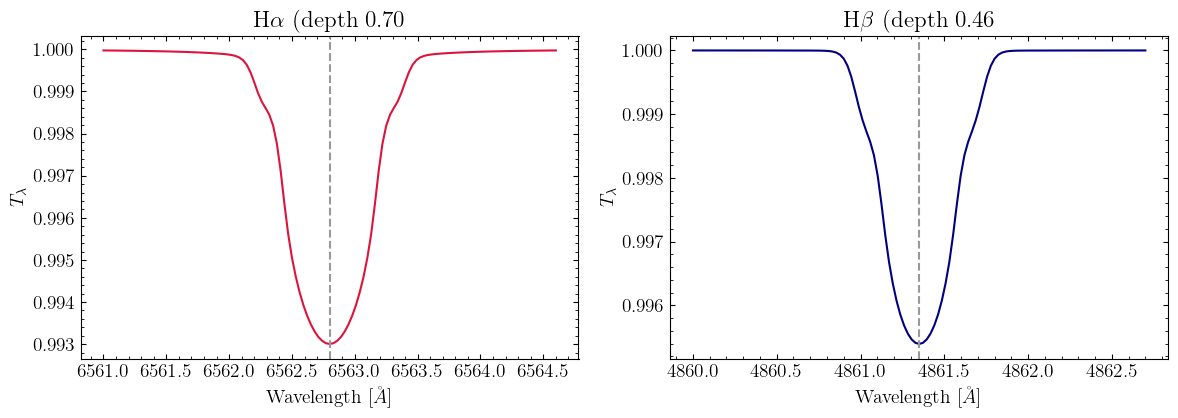

In [4]:
# Plot the model Balmer-line transmission spectra
fig,ax=plt.subplots(1,2,figsize=(12,4.4))
ax[0].plot(lam_Ha, T_Ha, color='crimson'); ax[0].axvline(6562.8,ls='--',color='0.6')
ax[0].set_title(r'H$\alpha$  (depth %.2f%%)'%depth_Ha)
ax[1].plot(lam_Hb, T_Hb, color='navy');    ax[1].axvline(4861.35,ls='--',color='0.6')
ax[1].set_title(r'H$\beta$  (depth %.2f%%)'%depth_Hb)
for a in ax: a.set_xlabel(r'Wavelength [$\AA$]'); a.set_ylabel(r'$T_\lambda$')
plt.tight_layout(); plt.show()

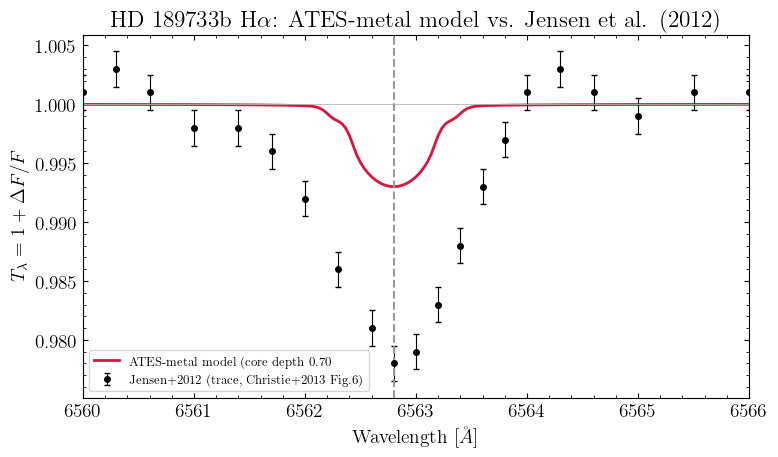

Model H-alpha core depth : 0.70 %
Observed (Jensen+2012)   : clean symmetric ~1.3 A dip, depth ~2.2%%
  Christie+2013 match this with xi=14 (boosted ionizing flux).


In [5]:
# ---- Comparison with Jensen et al. (2012), HD 189733b ----
# HD189733b is the CLEAN H-alpha detection (Christie+2013 Fig.6): a
# symmetric ~1.3 A dip of depth ~-2.2%, which their xi=14 model matches.
# This is the meaningful benchmark for the n=2 / Ly-alpha-pumping physics.
lam_cmp = np.linspace(6560.0, 6566.0, 181)
T_cmp   = transmission(lam_cmp*1e-10, nu_Ha, f_Ha, A12_Ha)

fig,ax=plt.subplots(figsize=(8,4.8))
ax.plot(lam_cmp, T_cmp, color='crimson', lw=2,
        label=r'EXHALE model (core depth %.2f%%)'%depth_Ha)
datafile='jensen2012_HD189733b_Ha.txt'
if os.path.exists(datafile):
    wl,dFF,derr=np.loadtxt(datafile,usecols=(0,1,2),unpack=True)
    ax.errorbar(wl, 1+dFF, yerr=derr, fmt='ko', ms=4, capsize=2, lw=0.8,
                label='Jensen+2012 (trace, Christie+2013 Fig.6)')
ax.axhline(1,color='0.7',lw=0.6); ax.axvline(6562.8,ls='--',color='0.6')
ax.set_xlim(6560,6566)
ax.set_xlabel(r'Wavelength [$\AA$]'); ax.set_ylabel(r'$T_\lambda = 1+\Delta F/F$')
ax.set_title('HD 189733b H$\\alpha$: EXHALE model vs. Jensen et al. (2012)')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

print('Model H-alpha core depth : %.2f %%' % depth_Ha)
print('Observed (Jensen+2012)   : clean symmetric ~1.3 A dip, depth ~2.2%%')
print('  Christie+2013 match this with xi=14 (boosted ionizing flux).')

## Discussion

- The model H$\alpha$ core depth for HD 189733b is **smaller than for HD 189733b**.
  A key reason in this simple model is that HD 209458's hotter G-star photosphere
  produces a much stronger Balmer continuum, so the $n=2$ photoionization rate
  $\Gamma_2$ is large (tens–hundreds of s$^{-1}$ vs. $\sim$25 s$^{-1}$ for the
  cooler K-star HD 189733), depleting the $n=2$ population that absorbs H$\alpha$.
- Christie et al. (2013) noted that their (symmetric) model **could not reproduce
  the asymmetric** H$\alpha$ line profile that Jensen et al. (2012) observed for
  HD 189733b; the present model is likewise symmetric (hydrostatic, no net wind
  asymmetry), so only the depth/width — not the asymmetry — can be compared.
- **Caveats / knobs:** the day-night $\xi$ factor (here from ATES's `Rate/2`),
  $F_{\rm LyC}$, $\Gamma_2$ (via `T_star`, `R_star`), and the uniform-illumination
  $J_{\rm Ly\alpha}$ estimate each shift the depth; supply a `Jlya_file` (and a
  measured Balmer-continuum $\Gamma_2$) for a more rigorous comparison.
- **To finish the comparison:** digitize the Jensen et al. (2012) HD 189733b
  H$\alpha$ profile into `jensen2012_HD189733b_Ha.txt` (columns: wavelength [A],
  $\Delta F/F$); it will be overplotted automatically above.